# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Fused Softmax
Reduces memory reads/writes by fusing multiple operations into one kernel

### GPU Properties
- Before writing kernel fetch GPU properties for computing occupancy, etc. and setting constants

In [4]:
properties = triton.runtime.driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"] # Number of streaming multi-processors (SM) on the GPU
NUM_REGS = properties["max_num_regs"] # Total 32-bit registers available per SM
SRAM_PER_SM = properties["max_shared_mem"] # Max shared memory available per SM
WARP_SIZE = properties["warpSize"] # Number of threads per warp

### Kernel and Wrapper

In [5]:
def naive_softmax(x):
    """
    x shape: [m, n]
    In row-wise softmax max element is subtracted for numerical stability. It does not change 
    the final probabilities as a constant is subtracted and it prevents exponentials from blowing up.
    """
    # Read m x n elements and find their max along n, and write m elements
    x_max = x.max(dim=1)[0]
    # Read m x n + m elements, and write m elements
    z = x - x_max[:, None] # Broadcast x_max. Max element is subtracted to avoid overflows
    # Read m x n elements and write m x n elements
    numerator = torch.exp(z)
    # Read m x n elements and write m elements
    denominator = numerator.sum(dim=1)
    # Read m x n + m elements and write m x n elements
    output = numerator / denominator[:, None]
    """
    Read: 5mn + 2m elements
    Write: 3mn + 2m elements
    Total operations: 8mn + 4m => A lot of memory operations
    """
    return output
    

@triton.jit
def softmax_kernel(
    input_ptr,
    output_ptr,
    input_row_stride, # Tells GPU how many elements pointer must skip over in memory to move from the start of one row to the start of the next
    output_row_stride, 
    n_rows,
    n_cols,
    BLOCK_SIZE: tl.constexpr,
    num_stages: tl.constexpr,
):
    # Starting row of the program
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0) # Each program will process every row_step row
    for row_idx in tl.range(row_start, n_rows, step=row_step, num_stages=num_stages):
        
        # Find input row start pointer for program with id row_start 
        row_start_ptr = input_ptr + row_idx * input_row_stride

        # Load row in SRAM
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask, other=float("-inf"))

        ## Softmax calculations
        # Subtract max row element for numerical stability
        row_minus_max = row - tl.max(row, axis=0) # axis=0 because row is a 1D local tensor
        numerator = tl.exp(row_minus_max) # exp(-inf) = 0
        denominator = tl.sum(numerator, axis=0) # All invalid values are 0
        output = numerator / denominator

        # Find output row start pointer
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        
        # Write output to DRAM
        tl.store(output_ptrs, value=output, mask=mask)


def softmax(x):
    assert x.ndim == 2
    n_rows, n_cols = x.shape

    # n_cols is used because of Memory Coalescing and the Row-Major layout of tensors
    # One p_id -> handles one row and loads the entire column width
    BLOCK_SIZE = triton.next_power_of_2(n_cols) 

    # Manual heuristic to ask the compiler to use more threads per row by increasing 
    # the number of warps over which each row is distributed
    num_warps = 4
    if BLOCK_SIZE >= 2048:
        num_warps = 8
    if BLOCK_SIZE >= 4096:
        num_warps = 16

    # Number of software pipelining stages. Software pipeling is a strategy for hiding the massive 
    # latency of moving data from the DRAM to the SRAM. CUDA: Prologue, Main-loop, Epilogue idea
    num_stages = 4 if SRAM_PER_SM > 200_000 else 2

    # Allocate output
    y = torch.empty_like(x)

    # Pre-compile kernel to get register usage and compute amount of shared memory needed
    kernel = softmax_kernel.warmup(
        input_ptr=x,
        output_ptr=y,
        input_row_stride=x.stride(0), # Number of cols in i/p to skip to reach start of next row in i/p
        output_row_stride=y.stride(0), # Number of cols in o/p to skip to reach start of next row in o/p
        n_rows=n_rows,
        n_cols=n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
        num_stages=num_stages,
        num_warps=num_warps, # Not in kernel signature?
        grid=(1,), # Not in kernel signature?
    )

    # After kernel is compiled, get its location (pointer) in GPU memory and other information
    kernel._init_handles()
    n_regs = kernel.n_regs # Number of registers
    size_smem = kernel.metadata.shared

    # Compute: Occupancy - tells how much of GPUs "parallel potential" is actually being used
    # TODO: Understand the math again
    reg_occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
    sram_occupancy = SRAM_PER_SM // size_smem
    occupancy = min(reg_occupancy, sram_occupancy)
    num_programs = NUM_SM * occupancy

    # Compute number of programs to run
    num_programs = min(num_programs, n_rows)

    # Define grid
    grid = (num_programs, 1, 1)

    # Run kernel
    kernel[grid](
        x,
        y,
        x.stride(0),
        y.stride(0),
        n_rows,
        n_cols,
        BLOCK_SIZE,
        num_stages,
    )

    return y

### Test and Benchmark Helpers

In [6]:
def test_softmax_kernel(size: tuple, atol=1e-6, rtol=1e-5, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)

    assert isinstance(size, tuple) and len(size) == 2
    
    # Create test data
    m, n = size
    x = torch.randn(m, n, device=device)

    # Run triton kernel and PyTorch equivalent
    z_triton = softmax(x)
    z_ref = torch.softmax(x, axis=1)

    # Compare
    torch.testing.assert_close(z_triton, z_ref, atol=atol, rtol=rtol)
    print("Passed")

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"], # x-axis for plot
        x_vals=[128 * i for i in range(1, 100)], # Different possible values for x_name
        x_log=True, # Log scale for x-axis,
        line_arg="provider",
        line_vals=["triton", "torch", "naive_softmax"],
        line_names=["Triton", "Torch", "Naive Softmax"], # Label names for the lines
        styles=[("blue", '-'), ("green", '-'), ("red", '-')], # Line styles
        ylabel="GB/sec", # Label name for y-axis
        plot_name="softmax-performance",
        args={'M': 4096}, # Values for function argument not in x_names and y_name
    )
)
def benchmark(M, N, provider):
    # Create input data
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

    # Create a new GPU stream and make subsequent GPU operations run on that stream
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)

    if provider == "torch":
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == "triton":
        # Call wrapper
        ms = triton.testing.do_bench(lambda: softmax(x))
    if provider == "naive_softmax":
        ms = triton.testing.do_bench(lambda: naive_softmax(x))

    # Calculate memory bandwidth of kernel
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3) # 2 is used because 1 read and 1 write

    return gbps(ms)

## Test

In [7]:
test_softmax_kernel((200, 300))
test_softmax_kernel((4096, 256))

Passed
Passed


## Benchmark

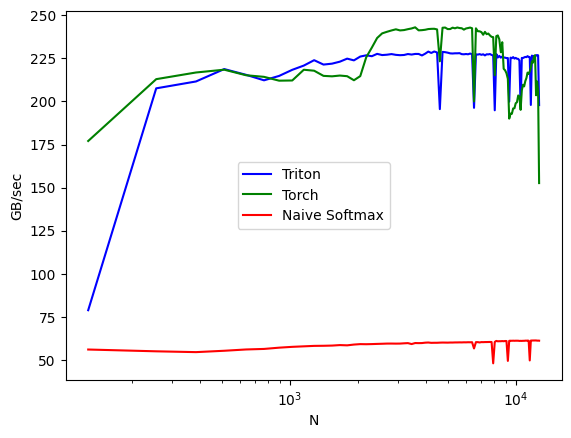

softmax-performance:
          N      Triton       Torch  Naive Softmax
0     128.0   78.885827  177.064505      56.076100
1     256.0  207.618009  212.941653      55.036517
2     384.0  211.604848  216.809634      54.565231
3     512.0  218.790975  218.436480      55.355476
4     640.0  215.454032  215.207066      56.109515
5     768.0  212.272630  214.284402      56.417258
6     896.0  214.828354  212.060056      57.153310
7    1024.0  218.358160  212.176449      57.629454
8    1152.0  220.824057  218.406417      57.924746
9    1280.0  223.949683  217.842979      58.185814
10   1408.0  221.402613  214.848007      58.248684
11   1536.0  221.940852  214.587934      58.362345
12   1664.0  223.095724  215.032536      58.650826
13   1792.0  224.848121  214.659915      58.499403
14   1920.0  223.849881  212.309875      58.951902
15   2048.0  226.064231  214.713607      59.209336
16   2176.0  226.777670  225.626473      59.155006
17   2304.0  226.258890  231.239917      59.230010
18   2432.

In [8]:
benchmark.run(print_data=True, show_plots=True)